In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = sp.symbols('x')

In [ ]:
user_input = input("Enter a function of x (e.g., x**3 - 3*x**2 + 2): ")
f = sp.sympify(user_input)

Enter a function of x (e.g., x**3 - 3*x**2 + 2): x**3-3*x**2+2


In [ ]:
f_prime = sp.diff(f, x)
print(f"\nFirst derivative f'(x): {f_prime}")


First derivative f'(x): 3*x**2 - 6*x


In [ ]:
critical_points = sp.solve(f_prime, x)
print(f"\nCritical Points: {critical_points}")


Critical Points: [0, 2]


In [ ]:
def classify_critical_point(point):
    delta = 0.01  # Small value to check sign change
    left = f_prime.subs(x, point - delta)
    right = f_prime.subs(x, point + delta)

    if left > 0 and right < 0:
        return "Local Maximum"
    elif left < 0 and right > 0:
        return "Local Minimum"
    else:
        return "Saddle/Inflection Point or No Change"

In [ ]:
print("\nClassification of Critical Points:")
classified_points = []
for cp in critical_points:
    classification = classify_critical_point(cp)
    value = f.subs(x, cp)
    print(f"x = {cp}, f(x) = {value}, Type: {classification}")
    classified_points.append((float(cp), float(value), classification))



Classification of Critical Points:
x = 0, f(x) = 2, Type: Local Maximum
x = 2, f(x) = -2, Type: Local Minimum


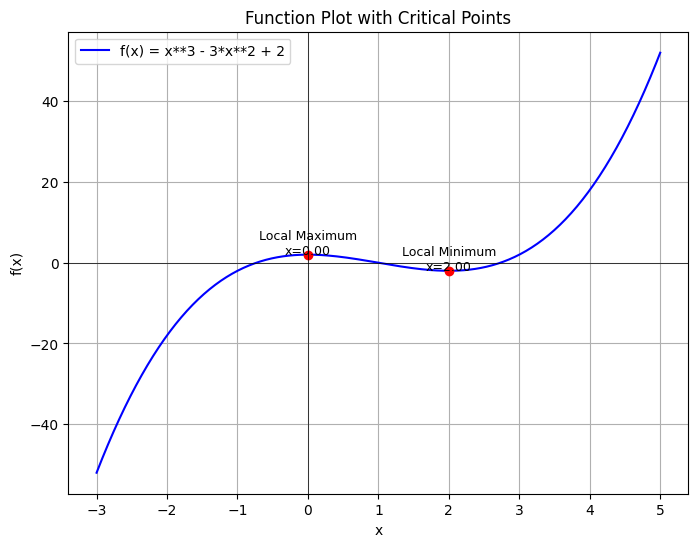

In [ ]:
try:
    # Convert symbolic function to numerical function
    f_numeric = sp.lambdify(x, f, modules=['numpy'])

    # Generate x values and corresponding y values
    x_vals = np.linspace(min([p[0] for p in classified_points]) - 3,
                         max([p[0] for p in classified_points]) + 3, 400)
    y_vals = f_numeric(x_vals)

    # Create plot
    plt.figure(figsize=(8, 6))
    plt.plot(x_vals, y_vals, label=f'f(x) = {f}', color='blue')

    # Plot critical points
    for cp_x, cp_y, label in classified_points:
        plt.plot(cp_x, cp_y, 'ro')
        plt.text(cp_x, cp_y, f'{label}\nx={cp_x:.2f}', fontsize=9, ha='center')

    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title("Function Plot with Critical Points")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)
    plt.legend()
    plt.show()

except Exception as e:
    print("Plotting failed. Please ensure matplotlib is installed.")
    print(f"Error: {e}")